# Client 3

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
    average_precision_score
)
from sklearn.pipeline import Pipeline as ImbPipeline

## Importer le dataset

In [2]:
# Chargement du dataset
df = pd.read_csv("../../data/Data_Arbre_Clean.csv")

df.head()

,X,Y,clc_quartier,clc_secteur,id_arbre,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,...,fk_revetement,dte_plantation,age_estim,clc_nbr_diag,dte_abattage,villeca,nomfrancais,nomlatin,feuillage,remarquable
0,1.720320e+06,8.294619e+06,Quartier du Centre-Ville,Boulevard Richelieu,24.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,2015-07-01T00:00:00Z,VILLE,NaN,NaN,NaN,False
1,1.720898e+06,8.293531e+06,Quartier du Centre-Ville,Boulevard Léon Blum,24.0,0.0,0.0,0.0,ABATTU,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
2,1.720894e+06,8.293542e+06,Quartier du Centre-Ville,Boulevard Léon Blum,53.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
3,1.720902e+06,8.293545e+06,Quartier du Centre-Ville,Boulevard Léon Blum,54.0,0.0,0.0,0.0,SUPPRIMÉ,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False
4,1.721089e+06,8.293619e+06,Quartier du Centre-Ville,Boulevard Léon Blum,63.0,0.0,0.0,0.0,ABATTU,NaN,...,NaN,NaN,0.0,0.0,NaN,VILLE,NaN,NaN,NaN,False


## Prétraitements

In [3]:
# Transformation logarithmique
for col in ["tronc_diam", "haut_tot", "haut_tronc", "age_estim", "X", "Y"]:
    df[col] = np.log1p(df[col])

# Définition des variables
CIBLE        = "fk_arb_etat"
ETATS_RISQUE = ["ABATTU", "Essouché", "SUPPRIMÉ", "REMPLACÉ", "Non essouché"]

FEATURES_NUM = ["tronc_diam", "haut_tot", "haut_tronc", "age_estim", "X", "Y"]
FEATURES_CAT = ["fk_port", "fk_pied", "nomfrancais", "clc_quartier", "clc_secteur"]
FEATURES     = FEATURES_NUM + FEATURES_CAT

X = df[FEATURES]
y = df[CIBLE].apply(lambda x: 1 if x in ETATS_RISQUE else 0)

In [4]:
print("Distribution fk_arb_etat :\n", df[CIBLE].value_counts())
print("\nMissing values :\n", X.isna().sum())
print("\nDistribution cible :\n", y.value_counts())

Distribution fk_arb_etat :
 fk_arb_etat
EN PLACE        9407
SUPPRIMÉ         445
Essouché         204
REMPLACÉ         187
ABATTU           113
Non essouché      62
Name: count, dtype: int64

Missing values :
 tronc_diam       13
haut_tot          0
haut_tronc        0
age_estim         3
X                 0
Y                 0
fk_port         145
fk_pied         121
nomfrancais     155
clc_quartier    485
clc_secteur       3
dtype: int64

Distribution cible :
 fk_arb_etat
0    9407
1    1011
Name: count, dtype: int64


## Split train/test

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Pipelines de preprocessing

In [6]:
# Numérique
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

# Catégoriel
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, FEATURES_NUM),
    ("cat", cat_pipeline, FEATURES_CAT)
])

In [7]:
pipeline = ImbPipeline([
    ("prep", preprocessor),
    ("clf",  RandomForestClassifier(random_state=42))
])

param_grid = {
    "clf__n_estimators":      [500],
    "clf__max_depth":         [None, 20],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf":  [1, 2],
    "clf__max_features":      ["sqrt"],
    "clf__class_weight":      [{0: 1, 1: 10}]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits


## Résultats

In [8]:
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleur F1 (CV)     : {grid.best_score_:.4f}")

Meilleurs paramètres : {'clf__class_weight': {0: 1, 1: 10}, 'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}
Meilleur F1 (CV)     : 0.7113


## Prédictions

In [9]:
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.2).astype(int)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2%}\n")
print(classification_report(y_test, y_pred))
print(f"Average Precision : {average_precision_score(y_test, y_proba):.3f}")

Accuracy : 92.99%

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1882
           1       0.63      0.68      0.65       202

    accuracy                           0.93      2084
   macro avg       0.80      0.82      0.81      2084
weighted avg       0.93      0.93      0.93      2084

Average Precision : 0.741


## Matrice de confusion

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :\n", cm)

Matrice de confusion :
 [[1801   81]
 [  65  137]]


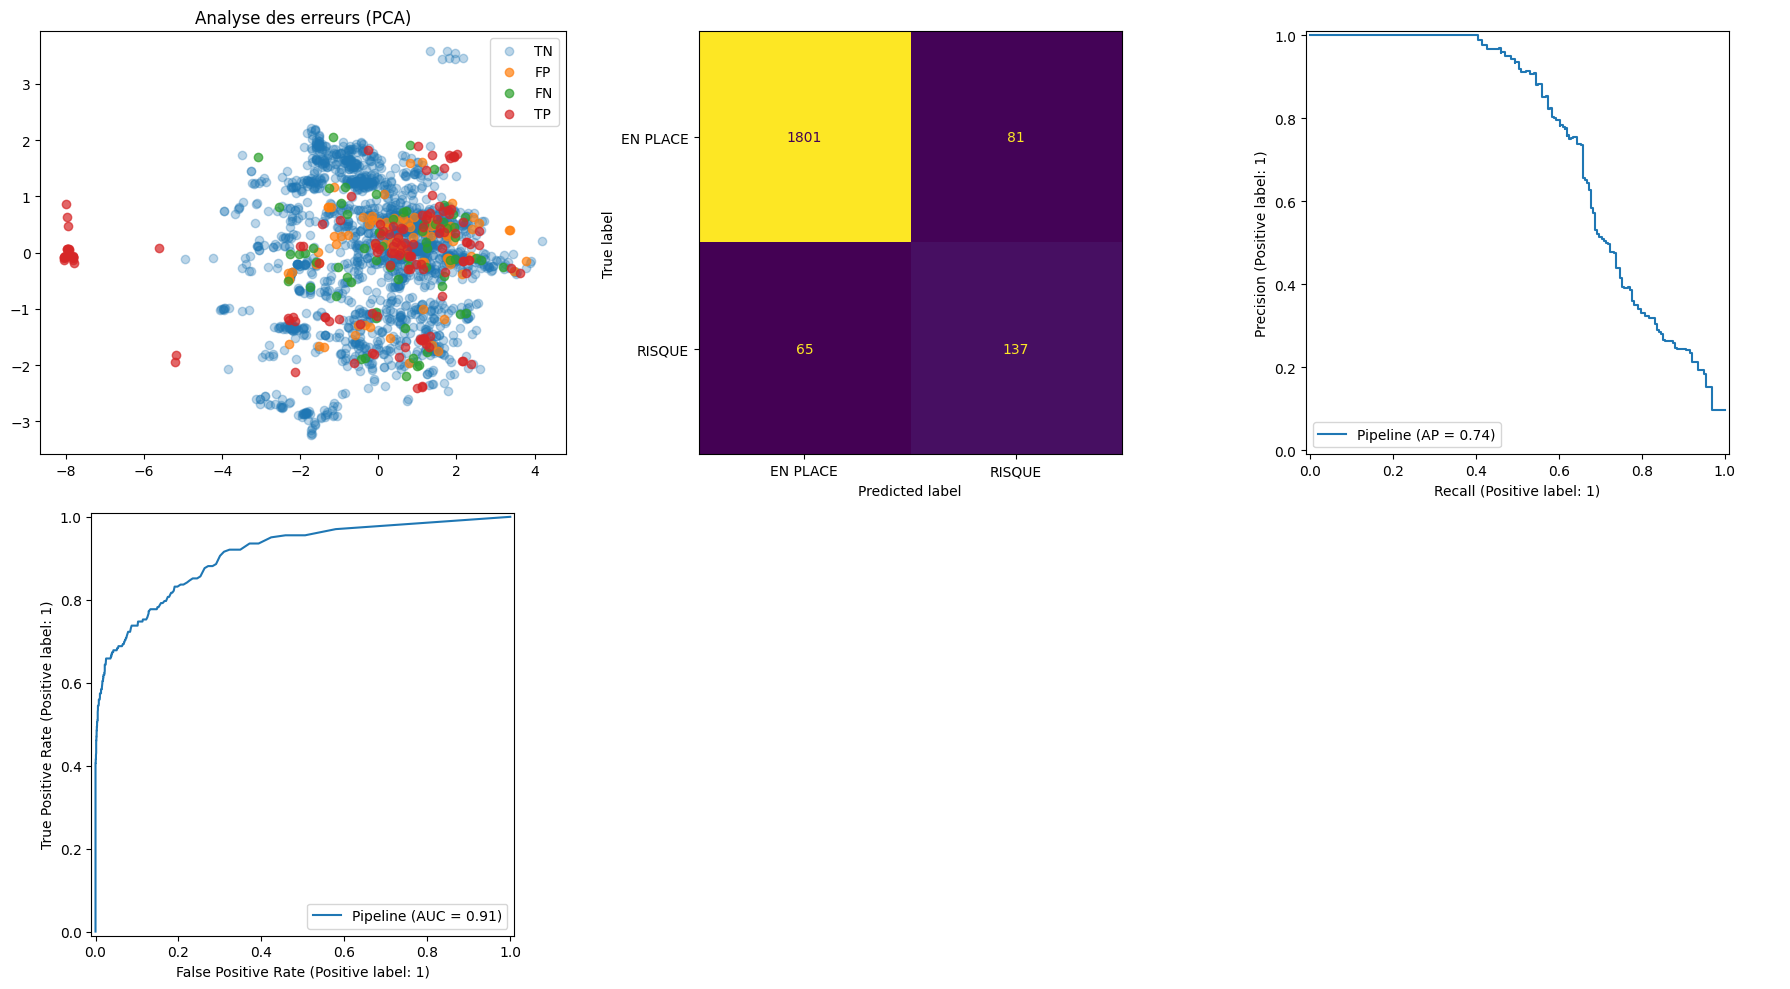

In [ ]:
X_test_proc = best_model.named_steps["prep"].transform(X_test)
X_pca = PCA(n_components=2).fit_transform(X_test_proc)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# PCA erreurs
configs = [
    ((y_test == 0) & (y_pred == 0), "TN", 0.3),
    ((y_test == 0) & (y_pred == 1), "FP", 0.7),
    ((y_test == 1) & (y_pred == 0), "FN", 0.7),
    ((y_test == 1) & (y_pred == 1), "TP", 0.7),
]

for mask, label, alpha in configs:
    axes[0, 0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                       label=label, alpha=alpha)

axes[0, 0].set_title("Analyse des erreurs (PCA)")
axes[0, 0].legend()

# Confusion
ConfusionMatrixDisplay(cm, display_labels=["EN PLACE", "RISQUE"]).plot(
    ax=axes[0, 1], colorbar=False
)

# Precision-Recall
PrecisionRecallDisplay.from_estimator(
    best_model, X_test, y_test, ax=axes[0, 2]
)

# ROC
RocCurveDisplay.from_estimator(
    best_model, X_test, y_test, ax=axes[1, 0]
)

axes[1, 1].axis("off")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

## Sauvegarde du modèle

In [12]:
joblib.dump(best_model, "modele_tempete.pkl")
print("Modèle sauvegardé : modele_tempete.pkl")

Modèle sauvegardé : modele_tempete.pkl
